[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/OceanNetworksCanada/python-community-notebooks/blob/main/workflows/transit-analysis/distance_from_terminals.ipynb)

In [ ]:
!uv pip install -q cartopy geopy onc xarray

In [2]:
# Bootstrap cell
import sys
from pathlib import Path
import os

def in_colab() -> bool:
    try:
        import google.colab
        return True
    except ImportError:
        return False

def setup_repo_for_shared_imports():
    """
    Locate (or clone, in Colab) the notebook repository and add it to ``sys.path``.

    Notes:
        - In Colab, this ensures the repository exists at
          ``/content/python-community-notebooks`` by cloning it if needed.
        - In local environments, this searches upward from the current working
          directory for ``shared`` to identify the repo root.
        - If a repo root is found, it is prepended to ``sys.path`` to enable
          imports from the repository (e.g., ``shared`` modules).
    """
    repo_dir: Path | None = None

    if in_colab():
        repo_dir = Path('/content/python-community-notebooks')
        if not repo_dir.exists():
            !git clone --depth 1 https://github.com/OceanNetworksCanada/python-community-notebooks.git /content/python-community-notebooks
    else:
        cwd = Path.cwd().resolve()
        for candidate in [cwd, *cwd.parents]:
            if (candidate / 'shared').exists():
                repo_dir = candidate
                break

    if repo_dir is not None and str(repo_dir) not in sys.path:
        sys.path.insert(0, str(repo_dir))



def init_token():   
    """
    Initialize the ONC_TOKEN environment variable.

    Notes:
        - If in Colab, add your ONC_TOKEN secrets by clicking the key icon on the left sidebar
        - If in local, create .env file in the root directory, and add ONC_TOKEN=XXX in your .env file
    """
    if in_colab():
        from google.colab import userdata
        os.environ['ONC_TOKEN'] = userdata.get('ONC_TOKEN')
    else:
        from dotenv import load_dotenv
        load_dotenv()

init_token()
setup_repo_for_shared_imports()

In [3]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from datetime import datetime, timedelta
from geopy import distance
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
from onc import ONC
import xarray as xr
import pandas as pd

from shared.IanTBlack_common import format_datetime, convert_scalar_data, calculate_distance_to_known_ports

In [4]:
onc = ONC()

In [5]:
date_from = datetime(2025,11,3,9,0,0)
date_to = datetime(2025,11,3,20,15,0)

In [6]:
# Download NAV
params = {'locationCode': 'TWDP.N1',
          'deviceCategoryCode': 'NAV',
          'qualityControl': 'clean',
          'dateFrom': format_datetime(date_from),
          'dateTo': format_datetime(date_to),
          'fillGaps': False}
json_response = onc.getScalardata(filters = params, allPages=True)
nav = convert_scalar_data(json_response_data = json_response, out_as = 'xarray')

In [7]:
nav = calculate_distance_to_known_ports(nav)

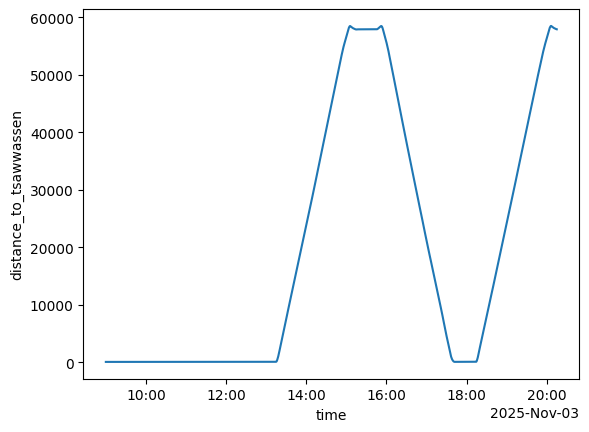

In [8]:
nav.distance_to_tsawwassen.dropna(dim = 'time').plot()